# Ensemble models on fingerprint baselines

This notebook follows **README** leaderboard choices: the top descriptor **`morgan_r1_count_1024`** with **HistGradientBoosting** (`hgb`), and we add **RandomForest** (`rf`) and **SVR** (`svr`) for model diversity (all appear among the best CV rows).

We wrap scikit-learn pipelines so they match the OpenADNet **`EnsembleRegressor`** / **`EnsembleQuantileRegressor`** API (`predict` / `predict_quantiles` on a small **`XYDataset`**).

**Plots:** test-set RMSE/MAE comparison (individual vs ensembles), observed–predicted scatter, and quantile metrics (pinball loss, interval width) for **`EnsembleQuantileRegressor`**.

Run from the repo root or `notebooks/`; the first code cell adds `src/` to the path. The first **`load_data.train`** import may download the training CSV from Hugging Face (cached afterward); set `HF_TOKEN` if rate-limited.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rdkit import Chem
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

_REPO = Path.cwd().resolve()
if not (_REPO / "src" / "baseline.py").exists():
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO / "src"))

from baseline import BaselineCVConfig, default_regressors, make_regressor_pipeline, prepare_training_data
from features_data import build_descriptor_matrix
from load_data import train
from models import EnsembleQuantileRegressor, EnsembleRegressor, pinball_loss

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 0
DESCRIPTOR = "morgan_r1_count_1024"  # README rank #0 (lowest mean RMSE)
Y_COL = "pEC50"

## Load molecules and build the descriptor matrix

Same pattern as `score_data.py` / `conformal_quantile_regression.ipynb`: valid SMILES + finite target.

In [2]:
mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y_all, mols_f, mask = prepare_training_data(train, mols, y_col=Y_COL)
X = build_descriptor_matrix(DESCRIPTOR, mols_f).astype(np.float64)
print(f"{DESCRIPTOR}: X {X.shape}, y {y_all.shape}, aligned rows {len(mols_f)}")

morgan_r1_count_1024: X (4140, 1024), y (4140,), aligned rows 4140


## Dataset wrapper and sklearn adapters

`EnsembleRegressor` / `EnsembleQuantileRegressor` expect `.y`, `n_tasks`, and `predict` / `predict_quantiles` that accept this dataset object.

In [3]:
class XYDataset:
    """Minimal regression dataset with numpy features (matches OpenADNet graph/SMILES layout)."""

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = np.asarray(X, dtype=np.float64)
        yy = np.asarray(y, dtype=np.float64)
        self.y = yy.reshape(-1, 1) if yy.ndim == 1 else yy

    @property
    def n_tasks(self) -> int:
        return int(self.y.shape[1])

    def __len__(self) -> int:
        return int(self.X.shape[0])


class SklearnMeanMember:
    """Single-task sklearn pipeline: ``predict`` -> (n, 1)."""

    def __init__(self, model_name: str, estimator) -> None:
        self.n_tasks = 1
        self._model_name = model_name
        self._estimator = estimator
        self._pipe = None

    def fit(self, dataset: XYDataset, **kwargs):
        self._pipe = make_regressor_pipeline(self._model_name, clone(self._estimator))
        self._pipe.fit(dataset.X, dataset.y.ravel())
        return []

    def predict(self, dataset: XYDataset, **kwargs) -> np.ndarray:
        p = self._pipe.predict(dataset.X)
        return np.asarray(p, dtype=np.float64).reshape(-1, 1)


class QuantileHGBMember:
    """Three HGB quantile models (same pipeline as ``hgb`` baseline); ``predict_quantiles`` -> (n, 1, 3)."""

    def __init__(self, quantile_levels: tuple[float, float, float], *, random_state: int) -> None:
        self.n_tasks = 1
        self.quantile_levels = quantile_levels
        self._rs = random_state
        self._pipes: list | None = None

    def fit(self, dataset: XYDataset, **kwargs):
        X, y = dataset.X, dataset.y.ravel()
        self._pipes = []
        for q in self.quantile_levels:
            base = HistGradientBoostingRegressor(
                loss="quantile",
                quantile=q,
                max_iter=200,
                random_state=self._rs,
            )
            pipe = make_regressor_pipeline("hgb", base)
            pipe.fit(X, y)
            self._pipes.append(pipe)
        return []

    def predict_quantiles(self, dataset: XYDataset, **kwargs) -> np.ndarray:
        if not self._pipes:
            raise RuntimeError("fit first")
        cols = [p.predict(dataset.X) for p in self._pipes]
        stacked = np.stack(cols, axis=-1)
        return stacked.reshape(stacked.shape[0], 1, stacked.shape[-1])

## Train / test split and baseline estimators

From `default_regressors()` we pick **`hgb`**, **`rf`**, **`svr`** (README-strong fingerprint models).

In [4]:
cfg = BaselineCVConfig(y_col=Y_COL, model_random_state=RANDOM_STATE)
regs = default_regressors(cfg.model_random_state)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)
ds_train = XYDataset(X_train, y_train)
ds_test = XYDataset(X_test, y_test)

names = ("hgb", "rf", "svr")
members = {
    "hgb": SklearnMeanMember("hgb", regs["hgb"]),
    "rf": SklearnMeanMember("rf", regs["rf"]),
    "svr": SklearnMeanMember("svr", regs["svr"]),
}
member_list = [members[k] for k in names]

ens_uniform = EnsembleRegressor(member_list)
ens_uniform.fit(ds_train)

print("Fitted via EnsembleRegressor:", ", ".join(names))

Fitted via EnsembleRegressor: hgb, rf, svr


In [5]:
def metrics_row(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}


rows = []
preds = {}
for k, m in zip(names, ens_uniform.models):
    p = m.predict(ds_test).ravel()
    preds[k] = p
    rows.append(metrics_row(k, ds_test.y, p))

p_uni = ens_uniform.predict(ds_test).ravel()
rows.append(metrics_row("ensemble (uniform)", ds_test.y, p_uni))
preds["ensemble (uniform)"] = p_uni

ens_weighted = EnsembleRegressor(
    list(ens_uniform.models),
    weights=[0.5, 0.25, 0.25],
)
p_w = ens_weighted.predict(ds_test).ravel()
rows.append(metrics_row("ensemble (0.5 hgb / 0.25 rf / 0.25 svr)", ds_test.y, p_w))
preds["ensemble (weighted)"] = p_w

metrics_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
display(metrics_df)

,model,rmse,mae,r2
0,ensemble (0.5 hgb / 0.25 rf / 0.25 svr),0.703018,0.517442,0.584481
1,hgb,0.704300,0.520242,0.582964
2,ensemble (uniform),0.712996,0.525256,0.572602
3,rf,0.743947,0.564401,0.534690
4,svr,0.811376,0.594557,0.446519


## `EnsembleQuantileRegressor`

Two **quantile HGB** stacks (same `morgan_r1_count_1024` features, different `random_state`) at levels **0.1 / 0.5 / 0.9**, combined with **`EnsembleQuantileRegressor`**. We report **pinball loss** (mean over quantiles) and compare **interval width** (distance between **q=0.9** and **q=0.1** predictions — a raw central band, not calibrated coverage) for each member vs the ensemble.

This is **not** conformal (no `ConformalizedQuantileRegressor` calibration step here); it illustrates averaging raw quantile surfaces.

In [6]:
QUANT_LEVELS = (0.1, 0.5, 0.9)

q_a = QuantileHGBMember(QUANT_LEVELS, random_state=RANDOM_STATE)
q_b = QuantileHGBMember(QUANT_LEVELS, random_state=RANDOM_STATE + 17)
q_a.fit(ds_train)
q_b.fit(ds_train)

ens_q = EnsembleQuantileRegressor(
    [q_a, q_b],
    quantile_levels=QUANT_LEVELS,
    weights=[0.5, 0.5],
)

def mean_pinball_over_quantiles(member: QuantileHGBMember, ds: XYDataset) -> float:
    P = member.predict_quantiles(ds)
    losses = [
        pinball_loss(ds.y, P[:, :, j], float(q))
        for j, q in enumerate(member.quantile_levels)
    ]
    return float(np.mean(losses))


pb_rows = [
    {
        "model": "quantile HGB (seed 0)",
        "pinball_mean": mean_pinball_over_quantiles(q_a, ds_test),
    },
    {
        "model": "quantile HGB (seed+17)",
        "pinball_mean": mean_pinball_over_quantiles(q_b, ds_test),
    },
    {
        "model": "EnsembleQuantileRegressor (0.5/0.5)",
        "pinball_mean": ens_q.evaluate_pinball_loss(ds_test),
    },
]
pinball_df = pd.DataFrame(pb_rows)
display(pinball_df)

# Per-quantile pinball for the ensemble
Pq = ens_q.predict_quantiles(ds_test)
y_te = ds_test.y
pinball_by_q = []
for j, q in enumerate(QUANT_LEVELS):
    pinball_by_q.append(
        pinball_loss(y_te, Pq[:, :, j], q),
    )
print("Ensemble pinball by quantile:", dict(zip(QUANT_LEVELS, pinball_by_q)))

# Interval width: q_hi - q_lo using 0.1 and 0.9 slices
lo_i, hi_i = 0, 2
w_a = q_a.predict_quantiles(ds_test)[:, 0, hi_i] - q_a.predict_quantiles(ds_test)[:, 0, lo_i]
w_b = q_b.predict_quantiles(ds_test)[:, 0, hi_i] - q_b.predict_quantiles(ds_test)[:, 0, lo_i]
w_e = Pq[:, 0, hi_i] - Pq[:, 0, lo_i]
print(
    "Mean interval width (0.1–0.9):",
    f"member_a={w_a.mean():.4f} member_b={w_b.mean():.4f} ensemble={w_e.mean():.4f}",
)

,model,pinball_mean
0,quantile HGB (seed 0),0.176513
1,quantile HGB (seed+17),0.176513
2,EnsembleQuantileRegressor (0.5/0.5),0.176513


Ensemble pinball by quantile: {0.1: 0.14997553404640568, 0.5: 0.26382766935423163, 0.9: 0.11573473906105172}
Mean interval width (0.1–0.9): member_a=1.4049 member_b=1.4049 ensemble=1.4049


## Plots

Bar chart of test **RMSE** (mean models + ensembles), **observed vs predicted** for the best single model and the weighted ensemble, and **distribution of interval widths** for the two quantile members vs **`EnsembleQuantileRegressor`**.

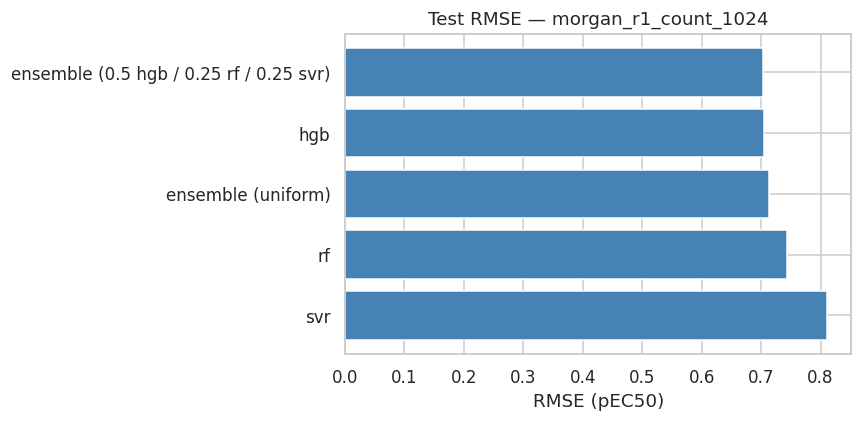

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = metrics_df.sort_values("rmse")
ax.barh(plot_df["model"], plot_df["rmse"], color="steelblue")
ax.set_title(f"Test RMSE — {DESCRIPTOR}")
ax.set_xlabel("RMSE (pEC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

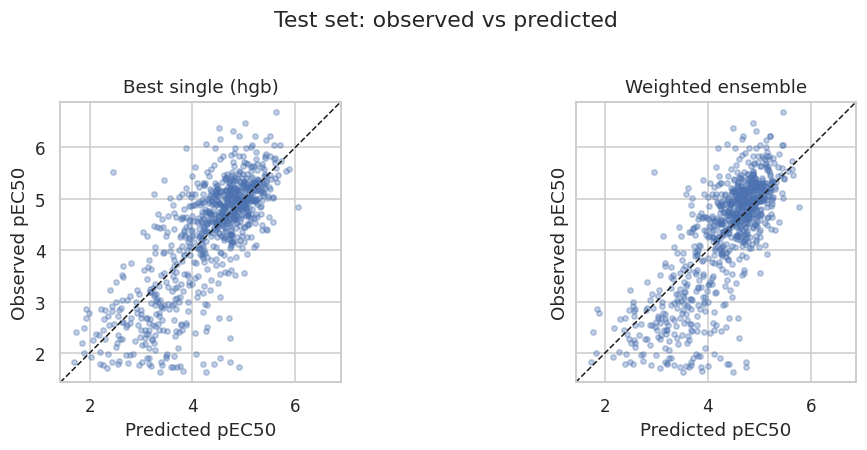

In [8]:
best_single = metrics_df[metrics_df["model"].isin(names)].sort_values("rmse").iloc[0]["model"]
y_obs = ds_test.y.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
lims = (y_obs.min() - 0.2, y_obs.max() + 0.2)
for ax, (title, key) in zip(
    axes,
    [
        (f"Best single ({best_single})", best_single),
        ("Weighted ensemble", "ensemble (weighted)"),
    ],
):
    pr = preds[key]
    ax.scatter(pr, y_obs, alpha=0.35, s=12)
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Predicted pEC50")
    ax.set_ylabel("Observed pEC50")
    ax.set_title(title)
plt.suptitle("Test set: observed vs predicted", y=1.02)
plt.tight_layout()
plt.show()

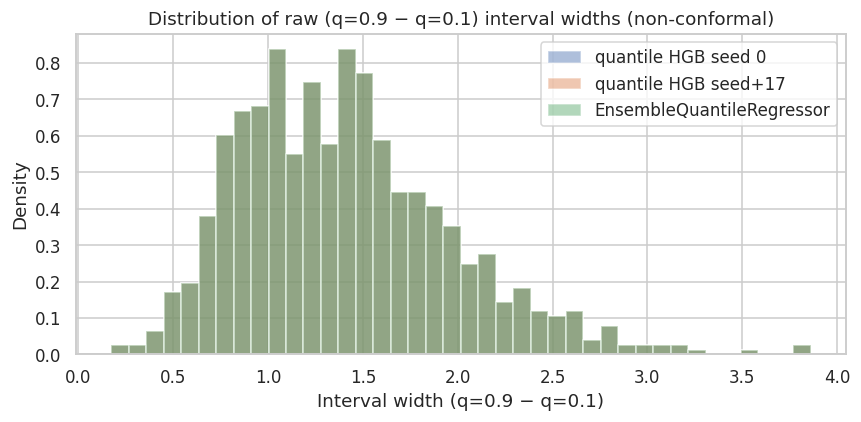

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(w_a, bins=40, alpha=0.45, label="quantile HGB seed 0", density=True)
ax.hist(w_b, bins=40, alpha=0.45, label="quantile HGB seed+17", density=True)
ax.hist(w_e, bins=40, alpha=0.45, label="EnsembleQuantileRegressor", density=True)
ax.set_xlabel("Interval width (q=0.9 − q=0.1)")
ax.set_ylabel("Density")
ax.set_title("Distribution of raw (q=0.9 − q=0.1) interval widths (non-conformal)")
ax.legend()
plt.tight_layout()
plt.show()

### Takeaways

- **Mean ensembles** blend inductive biases (boosting vs bagging vs kernel SVR). Whether RMSE improves vs the **best single** model depends on the draw; check `metrics_df` — `hgb` is usually strongest on this leaderboard setup.
- **Weighted ensembles** let you emphasize **`hgb`** when it dominates CV (README ranks).
- **`EnsembleQuantileRegressor`** averages full quantile surfaces; pinball loss and interval widths need not improve vs a single well-tuned HGB — the plot shows how dispersion changes.
- For **distribution-free coverage**, use **`uncertainty.ConformalizedQuantileRegressor`** (see `notebooks/conformal_quantile_regression.ipynb`).